In [1]:
!pip -q install onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 45.3 MB/s eta 0:00:00


In [2]:
import os
import re
import json
import time
import math
import hashlib
import random
import zipfile
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# -----------------------------
# Paths
# -----------------------------
DATA_DIR = "/content/sample_data"

TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
VAL_PATH = os.path.join(DATA_DIR, "val.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")

ARTIFACT_DIR = "/content/concierge_dl_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

ONNX_PATH = os.path.join(ARTIFACT_DIR, "intent_cnn.onnx")
VOCAB_PATH = os.path.join(ARTIFACT_DIR, "vocab.json")
LABEL_MAPPING_PATH = os.path.join(ARTIFACT_DIR, "label_mapping.json")
RUNTIME_CONFIG_PATH = os.path.join(ARTIFACT_DIR, "runtime_config.json")
METRICS_PATH = os.path.join(ARTIFACT_DIR, "metrics.json")
MODEL_CARD_PATH = os.path.join(ARTIFACT_DIR, "model_card.md")
PREDICTIONS_PATH = os.path.join(ARTIFACT_DIR, "test_predictions.csv")

# -----------------------------
# Fixed labels from your dataset
# -----------------------------
LABELS = [
    "faq",
    "support",
    "sales_or_leads",
    "human_request",
    "spam",
    "other",
]

label_to_id = {label: i for i, label in enumerate(LABELS)}
id_to_label = {i: label for label, i in label_to_id.items()}

# -----------------------------
# Model / training config
# -----------------------------
MAX_VOCAB_SIZE = 20000
MIN_TOKEN_FREQ = 1
MAX_LEN = 64

BATCH_SIZE = 64
EMBED_DIM = 128
NUM_FILTERS = 96
KERNEL_SIZES = [3, 4, 5]
DROPOUT = 0.35

LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 20
PATIENCE = 4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Artifact directory:", ARTIFACT_DIR)

Using device: cuda
Artifact directory: /content/concierge_dl_artifacts


In [4]:
def load_split(path: str, split_name: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{split_name} file not found at {path}. "
            "Upload it to /content/sample_data first."
        )

    df = pd.read_csv(path)

    expected_columns = {"text", "label"}
    actual_columns = set(df.columns)

    if actual_columns != expected_columns:
        raise ValueError(
            f"{split_name} must contain exactly these columns: {expected_columns}. "
            f"Found: {actual_columns}"
        )

    df["text"] = df["text"].fillna("").astype(str)
    df["label"] = df["label"].fillna("").astype(str)

    bad_labels = sorted(set(df["label"]) - set(LABELS))
    if bad_labels:
        raise ValueError(
            f"{split_name} contains labels not in LABELS: {bad_labels}"
        )

    return df


train_df = load_split(TRAIN_PATH, "train")
val_df = load_split(VAL_PATH, "val")
test_df = load_split(TEST_PATH, "test")

print("Train rows:", len(train_df))
print("Val rows:", len(val_df))
print("Test rows:", len(test_df))

display(train_df.head())

Train rows: 9016
Val rows: 1932
Test rows: 1932


,text,label
0,i dont know what i need to do to speak to a pe...,human_request
1,acquire several items,sales_or_leads
2,what trees change color in autumn,other
3,I want assistance to restore my user access key,support
4,can you help me sign up to the company newslet...,sales_or_leads


In [5]:
print("Train label distribution:")
display(train_df["label"].value_counts())

print("\nValidation label distribution:")
display(val_df["label"].value_counts())

print("\nTest label distribution:")
display(test_df["label"].value_counts())


def normalize_for_leak_check(text: str) -> str:
    return " ".join(str(text).lower().split())


train_texts = set(train_df["text"].map(normalize_for_leak_check))
val_texts = set(val_df["text"].map(normalize_for_leak_check))
test_texts = set(test_df["text"].map(normalize_for_leak_check))

train_val_overlap = train_texts & val_texts
train_test_overlap = train_texts & test_texts
val_test_overlap = val_texts & test_texts

print("Exact text overlap:")
print("train ∩ val:", len(train_val_overlap))
print("train ∩ test:", len(train_test_overlap))
print("val ∩ test:", len(val_test_overlap))

if train_test_overlap:
    print("\nWarning: Some exact messages appear in both train and test.")
    print("This can make test results look better than they really are.")

Train label distribution:


,count
label,
faq,2100
support,2100
sales_or_leads,2022
human_request,1399
other,945
spam,450



Validation label distribution:


,count
label,
support,450
faq,450
sales_or_leads,434
human_request,300
other,202
spam,96



Test label distribution:


,count
label,
support,450
faq,450
sales_or_leads,433
human_request,300
other,203
spam,96


Exact text overlap:
train ∩ val: 26
train ∩ test: 16
val ∩ test: 4

This can make test results look better than they really are.


In [6]:
def add_norm_text(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["_norm_text"] = df["text"].map(normalize_for_leak_check)
    return df


train_df = add_norm_text(train_df)
val_df = add_norm_text(val_df)
test_df = add_norm_text(test_df)

original_train_rows = len(train_df)
original_val_rows = len(val_df)
original_test_rows = len(test_df)

# Keep train as the source of learning.
train_norms = set(train_df["_norm_text"])

# Remove validation rows that also appear in train.
val_df = val_df[~val_df["_norm_text"].isin(train_norms)].copy()

# Remove test rows that appear in train.
test_df = test_df[~test_df["_norm_text"].isin(train_norms)].copy()

# Also remove test rows that appear in validation.
val_norms = set(val_df["_norm_text"])
test_df = test_df[~test_df["_norm_text"].isin(val_norms)].copy()

# Drop helper column.
train_df = train_df.drop(columns=["_norm_text"]).reset_index(drop=True)
val_df = val_df.drop(columns=["_norm_text"]).reset_index(drop=True)
test_df = test_df.drop(columns=["_norm_text"]).reset_index(drop=True)

print("Rows before cleaning:")
print("Train:", original_train_rows)
print("Val:", original_val_rows)
print("Test:", original_test_rows)

print("\nRows after cleaning:")
print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

# Re-check overlap
train_texts = set(train_df["text"].map(normalize_for_leak_check))
val_texts = set(val_df["text"].map(normalize_for_leak_check))
test_texts = set(test_df["text"].map(normalize_for_leak_check))

print("\nExact text overlap after cleaning:")
print("train ∩ val:", len(train_texts & val_texts))
print("train ∩ test:", len(train_texts & test_texts))
print("val ∩ test:", len(val_texts & test_texts))

Rows before cleaning:
Train: 9016
Val: 1932
Test: 1932

Rows after cleaning:
Train: 9016
Val: 1906
Test: 1912

Exact text overlap after cleaning:
train ∩ val: 0
train ∩ test: 0
val ∩ test: 0


In [7]:
TOKEN_PATTERN = re.compile(r"[a-zA-Z0-9_']+|[^\s]")


def tokenize(text: str) -> list[str]:
    text = str(text).lower().strip()
    return TOKEN_PATTERN.findall(text)


counter = Counter()

for text in train_df["text"]:
    counter.update(tokenize(text))

# Special tokens
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

vocab = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1,
}

for token, freq in counter.most_common():
    if freq < MIN_TOKEN_FREQ:
        continue
    if len(vocab) >= MAX_VOCAB_SIZE:
        break
    if token not in vocab:
        vocab[token] = len(vocab)

print("Vocabulary size:", len(vocab))
print("Most common tokens:", counter.most_common(20))

Vocabulary size: 5118
Most common tokens: [('i', 5904), ('to', 5858), ('{', 2298), ('}', 2298), ('the', 2292), ('a', 2191), ('help', 2001), ('can', 1813), ('do', 1771), ('?', 1615), ('how', 1451), ('account', 1422), ('what', 1324), ('my', 1320), ('me', 1319), ('need', 1287), ('of', 1201), ('have', 1034), ('assistance', 972), ('want', 957)]


In [8]:
def encode_text(text: str, vocab: dict[str, int], max_len: int) -> list[int]:
    tokens = tokenize(text)
    ids = [vocab.get(token, vocab[UNK_TOKEN]) for token in tokens]

    if len(ids) > max_len:
        ids = ids[:max_len]

    padding_needed = max_len - len(ids)
    if padding_needed > 0:
        ids = ids + [vocab[PAD_TOKEN]] * padding_needed

    return ids


def encode_dataframe(df: pd.DataFrame):
    X = np.array(
        [encode_text(text, vocab, MAX_LEN) for text in df["text"]],
        dtype=np.int64,
    )
    y = np.array(
        [label_to_id[label] for label in df["label"]],
        dtype=np.int64,
    )
    return X, y


X_train, y_train = encode_dataframe(train_df)
X_val, y_val = encode_dataframe(val_df)
X_test, y_test = encode_dataframe(test_df)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Example encoded message:")
print(X_train[0])
print("Original label:", train_df.iloc[0]["label"])
print("Encoded label:", y_train[0])

X_train shape: (9016, 64)
y_train shape: (9016,)
Example encoded message:
[ 2 89 24 14  2 17  3 10  3 64  3  7 59  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
Original label: human_request
Encoded label: 3


In [9]:
class IntentDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {
            "input_ids": self.X[idx],
            "label": self.y[idx],
        }


train_dataset = IntentDataset(X_train, y_train)
val_dataset = IntentDataset(X_val, y_val)
test_dataset = IntentDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# Class weights: useful if dataset is imbalanced
num_classes = len(LABELS)
class_counts = np.bincount(y_train, minlength=num_classes)

class_weights = len(y_train) / (num_classes * np.maximum(class_counts, 1))
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("Class counts:", dict(zip(LABELS, class_counts.tolist())))
print("Class weights:", dict(zip(LABELS, class_weights.detach().cpu().numpy().round(3).tolist())))

Class counts: {'faq': 2100, 'support': 2100, 'sales_or_leads': 2022, 'human_request': 1399, 'spam': 450, 'other': 945}
Class weights: {'faq': 0.7160000205039978, 'support': 0.7160000205039978, 'sales_or_leads': 0.7429999709129333, 'human_request': 1.0740000009536743, 'spam': 3.3389999866485596, 'other': 1.590000033378601}


In [10]:
class IntentCNN(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        num_classes: int,
        num_filters: int,
        kernel_sizes: list[int],
        dropout: float,
        pad_idx: int = 0,
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_idx,
        )

        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=embed_dim,
                out_channels=num_filters,
                kernel_size=k,
            )
            for k in kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, input_ids):
        # input_ids shape: [batch_size, max_len]
        embedded = self.embedding(input_ids)

        # Conv1d expects: [batch_size, embed_dim, max_len]
        embedded = embedded.transpose(1, 2)

        pooled_outputs = []

        for conv in self.convs:
            x = torch.relu(conv(embedded))

            # Global max pooling over sequence length
            x = torch.max(x, dim=2).values
            pooled_outputs.append(x)

        x = torch.cat(pooled_outputs, dim=1)
        x = self.dropout(x)
        logits = self.fc(x)

        return logits


model = IntentCNN(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    num_classes=len(LABELS),
    num_filters=NUM_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    dropout=DROPOUT,
    pad_idx=vocab[PAD_TOKEN],
).to(DEVICE)

print(model)

IntentCNN(
  (embedding): Embedding(5118, 128, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(128, 96, kernel_size=(3,), stride=(1,))
    (1): Conv1d(128, 96, kernel_size=(4,), stride=(1,))
    (2): Conv1d(128, 96, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.35, inplace=False)
  (fc): Linear(in_features=288, out_features=6, bias=True)
)


In [11]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)


def run_train_epoch(model, loader):
    model.train()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        optimizer.zero_grad()

        logits = model(input_ids)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * input_ids.size(0)

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }


@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        logits = model(input_ids)
        loss = criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        total_loss += loss.item() * input_ids.size(0)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs),
    }

In [12]:
best_val_macro_f1 = -1.0
best_state = None
epochs_without_improvement = 0

history = []

for epoch in range(1, EPOCHS + 1):
    train_metrics = run_train_epoch(model, train_loader)
    val_metrics = evaluate(model, val_loader)

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "train_weighted_f1": train_metrics["weighted_f1"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"],
    }

    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss={row['train_loss']:.4f} "
        f"train macro-F1={row['train_macro_f1']:.4f} | "
        f"val loss={row['val_loss']:.4f} "
        f"val macro-F1={row['val_macro_f1']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_macro_f1:
        best_val_macro_f1 = val_metrics["macro_f1"]
        best_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }
        epochs_without_improvement = 0
        print("  New best model saved.")
    else:
        epochs_without_improvement += 1
        print(f"  No improvement for {epochs_without_improvement} epoch(s).")

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

# Load best model
model.load_state_dict(best_state)
model.to(DEVICE)

history_df = pd.DataFrame(history)
display(history_df)

Epoch 01 | train loss=0.4914 train macro-F1=0.8282 | val loss=0.1354 val macro-F1=0.9560
  New best model saved.
Epoch 02 | train loss=0.0969 train macro-F1=0.9730 | val loss=0.0812 val macro-F1=0.9713
  New best model saved.
Epoch 03 | train loss=0.0415 train macro-F1=0.9903 | val loss=0.0608 val macro-F1=0.9779
  New best model saved.
Epoch 04 | train loss=0.0228 train macro-F1=0.9958 | val loss=0.0513 val macro-F1=0.9801
  New best model saved.
Epoch 05 | train loss=0.0141 train macro-F1=0.9978 | val loss=0.0465 val macro-F1=0.9835
  New best model saved.
Epoch 06 | train loss=0.0100 train macro-F1=0.9986 | val loss=0.0452 val macro-F1=0.9823
  No improvement for 1 epoch(s).
Epoch 07 | train loss=0.0065 train macro-F1=0.9990 | val loss=0.0458 val macro-F1=0.9868
  New best model saved.
Epoch 08 | train loss=0.0058 train macro-F1=0.9990 | val loss=0.0476 val macro-F1=0.9851
  No improvement for 1 epoch(s).
Epoch 09 | train loss=0.0044 train macro-F1=0.9994 | val loss=0.0425 val macro

,epoch,train_loss,train_accuracy,train_macro_f1,train_weighted_f1,val_loss,val_accuracy,val_macro_f1,val_weighted_f1
0,1,0.491367,0.843944,0.828202,0.844864,0.135437,0.956978,0.955955,0.957249
1,2,0.096893,0.973270,0.973020,0.973337,0.081194,0.973242,0.971329,0.973343
2,3,0.041484,0.989685,0.990333,0.989689,0.060774,0.980063,0.977931,0.980099
3,4,0.022809,0.995453,0.995775,0.995453,0.051334,0.981637,0.980121,0.981698
4,5,0.014142,0.997560,0.997758,0.997561,0.046451,0.985310,0.983515,0.985320
5,6,0.009987,0.998447,0.998596,0.998447,0.045165,0.984260,0.982308,0.984327
6,7,0.006507,0.998780,0.998951,0.998780,0.045770,0.988458,0.986792,0.988460
7,8,0.005809,0.998780,0.999027,0.998780,0.047578,0.986884,0.985095,0.986906
8,9,0.004367,0.999335,0.999424,0.999334,0.042471,0.985834,0.984248,0.985850
9,10,0.004999,0.999778,0.999647,0.999778,0.035971,0.989507,0.989244,0.989517


Final test metrics:
Accuracy: 0.9854
Macro-F1: 0.981
Weighted-F1: 0.9854

Per-class report:
                precision    recall  f1-score   support

           faq     0.9955    0.9910    0.9933       446
       support     0.9887    0.9820    0.9853       444
sales_or_leads     0.9907    0.9883    0.9895       429
 human_request     0.9866    1.0000    0.9932       294
          spam     0.9688    0.9688    0.9688        96
         other     0.9512    0.9606    0.9559       203

      accuracy                         0.9854      1912
     macro avg     0.9802    0.9818    0.9810      1912
  weighted avg     0.9854    0.9854    0.9854      1912



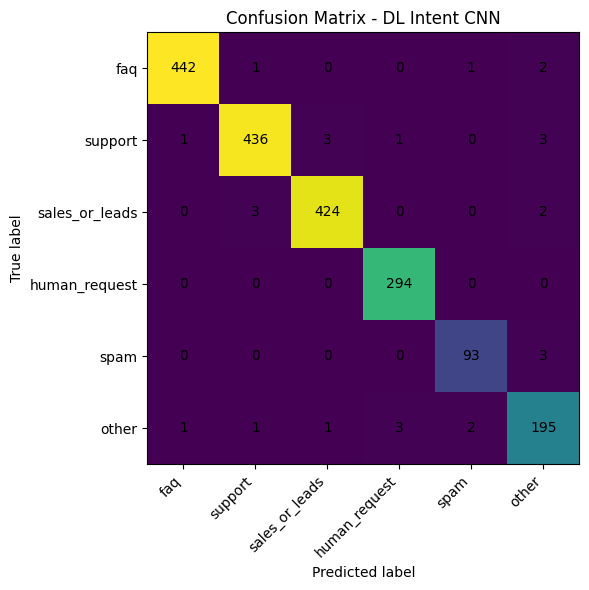

In [13]:
test_metrics = evaluate(model, test_loader)

print("Final test metrics:")
print("Accuracy:", round(test_metrics["accuracy"], 4))
print("Macro-F1:", round(test_metrics["macro_f1"], 4))
print("Weighted-F1:", round(test_metrics["weighted_f1"], 4))

print("\nPer-class report:")
report_text = classification_report(
    test_metrics["labels"],
    test_metrics["preds"],
    labels=list(range(len(LABELS))),
    target_names=LABELS,
    digits=4,
)

print(report_text)

report_dict = classification_report(
    test_metrics["labels"],
    test_metrics["preds"],
    labels=list(range(len(LABELS))),
    target_names=LABELS,
    digits=4,
    output_dict=True,
)

cm = confusion_matrix(
    test_metrics["labels"],
    test_metrics["preds"],
    labels=list(range(len(LABELS))),
)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix - DL Intent CNN")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(range(len(LABELS)), LABELS, rotation=45, ha="right")
plt.yticks(range(len(LABELS)), LABELS)

for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [15]:
!pip -q install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 16.2 MB/s eta 0:00:00


In [17]:
# Safer ONNX export: single ONNX file, no external .data file

import os
import glob
import torch

# Remove old ONNX files if they exist
for old_file in glob.glob(os.path.join(ARTIFACT_DIR, "intent_cnn.onnx*")):
    os.remove(old_file)

model.eval()
model.cpu()

dummy_input = torch.zeros((1, MAX_LEN), dtype=torch.long)

torch.onnx.export(
    model,
    dummy_input,
    ONNX_PATH,
    input_names=["input_ids"],
    output_names=["logits"],
    dynamic_axes={
        "input_ids": {0: "batch_size"},
        "logits": {0: "batch_size"},
    },
    opset_version=17,
    dynamo=False,
)

print("Exported ONNX model to:", ONNX_PATH)
print("ONNX size MB:", round(os.path.getsize(ONNX_PATH) / (1024 * 1024), 2))

print("\nFiles in artifact directory:")
!ls -lh /content/concierge_dl_artifacts

/tmp/ipykernel_504/2416220420.py:16: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Exported ONNX model to: /content/concierge_dl_artifacts/intent_cnn.onnx
ONNX size MB: 3.07

Files in artifact directory:
total 3.1M
-rw-r--r-- 1 root root 3.1M May 26 14:29 intent_cnn.onnx


In [18]:
import onnxruntime as ort

session = ort.InferenceSession(
    ONNX_PATH,
    providers=["CPUExecutionProvider"],
)

def softmax_np(logits: np.ndarray) -> np.ndarray:
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp = np.exp(logits)
    return exp / np.sum(exp, axis=1, keepdims=True)


def predict_onnx(texts: list[str]):
    encoded = np.array(
        [encode_text(text, vocab, MAX_LEN) for text in texts],
        dtype=np.int64,
    )

    logits = session.run(
        ["logits"],
        {"input_ids": encoded},
    )[0]

    probs = softmax_np(logits)
    pred_ids = np.argmax(probs, axis=1)

    results = []

    for text, pred_id, prob_row in zip(texts, pred_ids, probs):
        results.append({
            "text": text,
            "label": id_to_label[int(pred_id)],
            "confidence": float(np.max(prob_row)),
            "probabilities": {
                id_to_label[i]: float(prob_row[i])
                for i in range(len(LABELS))
            },
        })

    return results


sample_messages = [
    "What are your opening hours?",
    "I want to speak to a real person",
    "Can someone contact me about pricing?",
    "My account is not working",
    "win a free iphone click this link",
    "hello there",
]

onnx_results = predict_onnx(sample_messages)

for result in onnx_results:
    print(result["text"])
    print(" ->", result["label"], "| confidence:", round(result["confidence"], 4))
    print()

What are your opening hours?
 -> sales_or_leads | confidence: 0.7164

I want to speak to a real person
 -> human_request | confidence: 0.9455

Can someone contact me about pricing?
 -> human_request | confidence: 0.9664

My account is not working
 -> other | confidence: 0.8822

win a free iphone click this link
 -> other | confidence: 0.6434

hello there
 -> faq | confidence: 0.5578



In [19]:
latency_texts = test_df["text"].head(500).tolist()

# Warmup
_ = predict_onnx(latency_texts[:10])

start = time.perf_counter()
_ = predict_onnx(latency_texts)
end = time.perf_counter()

total_time = end - start
avg_ms_per_message = (total_time / len(latency_texts)) * 1000

print("Messages tested:", len(latency_texts))
print("Total ONNX inference time seconds:", round(total_time, 4))
print("Average ms/message:", round(avg_ms_per_message, 4))

Messages tested: 500
Total ONNX inference time seconds: 0.4305
Average ms/message: 0.861


In [20]:
def sha256_file(path: str) -> str:
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)

    return h.hexdigest()


with open(VOCAB_PATH, "w", encoding="utf-8") as f:
    json.dump(vocab, f, indent=2, ensure_ascii=False)

with open(LABEL_MAPPING_PATH, "w", encoding="utf-8") as f:
    json.dump(
        {
            "label_to_id": label_to_id,
            "id_to_label": id_to_label,
        },
        f,
        indent=2,
        ensure_ascii=False,
    )

runtime_config = {
    "model_type": "IntentCNN",
    "task": "visitor_message_intent_classification",
    "input_column": "text",
    "label_column": "label",
    "labels": LABELS,
    "max_len": MAX_LEN,
    "token_pattern": TOKEN_PATTERN.pattern,
    "pad_token": PAD_TOKEN,
    "unk_token": UNK_TOKEN,
    "pad_id": vocab[PAD_TOKEN],
    "unk_id": vocab[UNK_TOKEN],
    "max_vocab_size": MAX_VOCAB_SIZE,
    "min_token_freq": MIN_TOKEN_FREQ,
    "embed_dim": EMBED_DIM,
    "num_filters": NUM_FILTERS,
    "kernel_sizes": KERNEL_SIZES,
    "dropout": DROPOUT,
}

with open(RUNTIME_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(runtime_config, f, indent=2, ensure_ascii=False)

metrics = {
    "dataset": {
        "train_rows": int(len(train_df)),
        "val_rows": int(len(val_df)),
        "test_rows": int(len(test_df)),
        "labels": LABELS,
        "train_csv_sha256": sha256_file(TRAIN_PATH),
        "val_csv_sha256": sha256_file(VAL_PATH),
        "test_csv_sha256": sha256_file(TEST_PATH),
    },
    "training": {
        "seed": SEED,
        "batch_size": BATCH_SIZE,
        "epochs_requested": EPOCHS,
        "epochs_ran": int(len(history_df)),
        "best_val_macro_f1": float(best_val_macro_f1),
        "learning_rate": LR,
        "weight_decay": WEIGHT_DECAY,
        "patience": PATIENCE,
    },
    "test": {
        "accuracy": float(test_metrics["accuracy"]),
        "macro_f1": float(test_metrics["macro_f1"]),
        "weighted_f1": float(test_metrics["weighted_f1"]),
        "classification_report": report_dict,
    },
    "latency": {
        "onnx_avg_ms_per_message_cpu": float(avg_ms_per_message),
        "latency_sample_size": int(len(latency_texts)),
    },
    "artifacts": {
        "onnx_path": ONNX_PATH,
        "onnx_sha256": sha256_file(ONNX_PATH),
        "onnx_size_mb": round(os.path.getsize(ONNX_PATH) / (1024 * 1024), 4),
        "vocab_path": VOCAB_PATH,
        "vocab_sha256": sha256_file(VOCAB_PATH),
        "label_mapping_path": LABEL_MAPPING_PATH,
        "runtime_config_path": RUNTIME_CONFIG_PATH,
    },
}

with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print("Saved:")
print(VOCAB_PATH)
print(LABEL_MAPPING_PATH)
print(RUNTIME_CONFIG_PATH)
print(METRICS_PATH)

print("\nONNX SHA-256:")
print(metrics["artifacts"]["onnx_sha256"])

Saved:
/content/concierge_dl_artifacts/vocab.json
/content/concierge_dl_artifacts/label_mapping.json
/content/concierge_dl_artifacts/runtime_config.json
/content/concierge_dl_artifacts/metrics.json

ONNX SHA-256:
63a55ebb9eef1585f1ccf7f1f800484df0c5056f90ce6e7ee4577fe7d3efb19f


In [22]:
model_card = f"""# Model Card: Concierge DL Intent Classifier

## Task Description

This model classifies incoming visitor messages into one of six router categories:

- faq
- support
- sales_or_leads
- human_request
- spam
- other

The classifier is used before the main Concierge system decides whether to answer with RAG, capture a lead, escalate to a human, drop spam, or send the message to the agent.

## Dataset

The final dataset is split into three CSV files:

| Split | Rows |
|---|---:|
| train.csv | {len(train_df)} |
| val.csv | {len(val_df)} |
| test.csv | {len(test_df)} |

Each file has two columns:

- `text`: visitor message
- `label`: correct router class

## Dataset Hashes

| File | SHA-256 |
|---|---|
| train.csv | `{metrics["dataset"]["train_csv_sha256"]}` |
| val.csv | `{metrics["dataset"]["val_csv_sha256"]}` |
| test.csv | `{metrics["dataset"]["test_csv_sha256"]}` |

## Model

Architecture: small word-level CNN text classifier.

The model uses:

- custom regex tokenizer
- learned embedding layer
- multiple Conv1D filters
- global max pooling
- dropout
- linear classification head

This is a deep learning model trained offline in Colab and exported to ONNX for lean serving.

## Training Setup

| Setting | Value |
|---|---:|
| Seed | {SEED} |
| Max sequence length | {MAX_LEN} |
| Vocabulary size | {len(vocab)} |
| Batch size | {BATCH_SIZE} |
| Learning rate | {LR} |
| Weight decay | {WEIGHT_DECAY} |
| Epochs ran | {len(history_df)} |
| Best validation macro-F1 | {best_val_macro_f1:.4f} |

## Test Results

| Metric | Value |
|---|---:|
| Accuracy | {test_metrics["accuracy"]:.4f} |
| Macro-F1 | {test_metrics["macro_f1"]:.4f} |
| Weighted-F1 | {test_metrics["weighted_f1"]:.4f} |
| ONNX CPU latency, avg ms/message | {avg_ms_per_message:.4f} |

## Per-Class Results

```text
{report_text}
Artifact
Artifact	    Value
ONNX file	    :intent_cnn.onnx
ONNX SHA-256	:{metrics["artifacts"]["onnx_sha256"]}
ONNX size MB	:{metrics["artifacts"]["onnx_size_mb"]}

Deployment Choice

This DL model is exported to ONNX and should be served with onnxruntime.

The serving container should not include PyTorch or transformers. It only needs:

onnxruntime
numpy
the saved vocab.json
the saved label_mapping.json
the saved runtime_config.json

Limitations:
The tokenizer is simple and word-level, so it may not handle all typos or rare wording perfectly.
The model predicts one label per message only.
Ambiguous messages may still require fallback to the agent in the production router.
Confidence thresholding is not applied in this notebook; this notebook reports normal classification performance.

Files Produced:
intent_cnn.onnx
vocab.json
label_mapping.json
runtime_config.json
metrics.json
test_predictions.csv
model_card.md
"""
with open(MODEL_CARD_PATH, "w", encoding="utf-8") as f:
 f.write(model_card)

print(model_card[:2000])
print("\nSaved model card to:", MODEL_CARD_PATH)



# Model Card: Concierge DL Intent Classifier

## Task Description

This model classifies incoming visitor messages into one of six router categories:

- faq
- support
- sales_or_leads
- human_request
- spam
- other

The classifier is used before the main Concierge system decides whether to answer with RAG, capture a lead, escalate to a human, drop spam, or send the message to the agent.

## Dataset

The final dataset is split into three CSV files:

| Split | Rows |
|---|---:|
| train.csv | 9016 |
| val.csv | 1906 |
| test.csv | 1912 |

Each file has two columns:

- `text`: visitor message
- `label`: correct router class

## Dataset Hashes

| File | SHA-256 |
|---|---|
| train.csv | `52c68f2576cdb867fef1d19d778c50a19d8009be99a8ee0f8d2f55f74de917b8` |
| val.csv | `376775125c32c3789f3445189895492aa97ca861f14e84cf3efd967bd36a8356` |
| test.csv | `ef857cd3f1b5b65f4a3cf9be4885ee79954f687744209546067878d20c47d13d` |

## Model

Architecture: small word-level CNN text classifier.

The model use

In [26]:

ZIP_PATH = "/content/concierge_dl_artifacts.zip"

artifact_files = [
    ONNX_PATH,
    VOCAB_PATH,
    LABEL_MAPPING_PATH,
    RUNTIME_CONFIG_PATH,
    METRICS_PATH,
    MODEL_CARD_PATH,
]

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as z:
    for file_path in artifact_files:
        z.write(file_path, arcname=os.path.basename(file_path))

print("Created zip:", ZIP_PATH)
print("Zip size MB:", round(os.path.getsize(ZIP_PATH) / (1024 * 1024), 2))

from google.colab import files
files.download(ZIP_PATH)

Created zip: /content/concierge_dl_artifacts.zip
Zip size MB: 2.88


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>